# Image Stitching (Szeliski-inspired) — Step-by-step notebook

Notebook ini mengimplementasikan alur:
**preprocessing → feature detection (SIFT) → feature matching → RANSAC homography → warping → blending**.  
Setiap langkah divisualisasikan (keypoints, matches, warped image, panorama final).

Referensi utama: *Computer Vision* — Richard Szeliski (Computer_Vision_Richard_Szeliski.pdf).


In [ ]:
# Cell: Imports & helper functions
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
%matplotlib inline

def show(img, title=None, figsize=(10,6), cmap=None):
    plt.figure(figsize=figsize)
    if img is None:
        print("None image")
        return
    if len(img.shape)==2 or cmap is not None:
        plt.imshow(img, cmap=cmap)
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

def draw_keypoints_bgr(img, kps):
    return cv2.drawKeypoints(img, kps, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

def draw_matches_bgr(img1, kps1, img2, kps2, matches, mask=None, max_display=100):
    mlist = matches[:max_display]
    return cv2.drawMatches(img1, kps1, img2, kps2, mlist, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)


In [ ]:
# Cell: Configure detector (SIFT)
use_sift = True
nfeatures = 5000

if use_sift:
    try:
        detector = cv2.SIFT_create(nfeatures=nfeatures)
        descriptor_method = 'SIFT'
        print("Using SIFT detector")
    except Exception as e:
        print("SIFT not available in this OpenCV build:", e)
        print("Please install opencv-contrib-python or set use_sift=False")
        raise
else:
    detector = cv2.ORB_create(nfeatures=nfeatures)
    descriptor_method = 'ORB'
    print("Using ORB detector")


Using SIFT detector


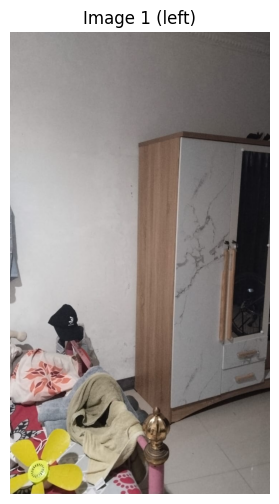

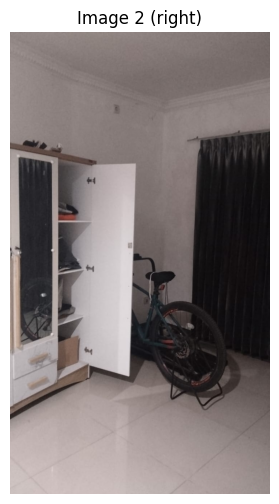

In [ ]:
# Cell: Load images (ganti path sesuai file yang kamu upload)
# Place your overlapping images in the working directory or images/ folder
img1_path = "left.jpg"    # ganti kalau nama lain
img2_path = "right.jpg"   # ganti kalau nama lain

# fallback: coba folder images/
import os
if not os.path.exists(img1_path) and os.path.exists("images/left.jpg"):
    img1_path = "images/left.jpg"
if not os.path.exists(img2_path) and os.path.exists("images/right.jpg"):
    img2_path = "images/right.jpg"

img1 = cv2.imread(img1_path)
img2 = cv2.imread(img2_path)
if img1 is None or img2 is None:
    raise FileNotFoundError(f"Could not load images. Checked: {img1_path}, {img2_path}")

show(img1, "Image 1 (left)")
show(img2, "Image 2 (right)")


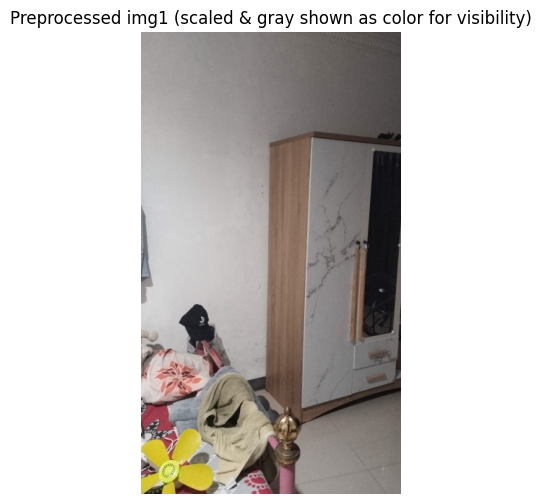

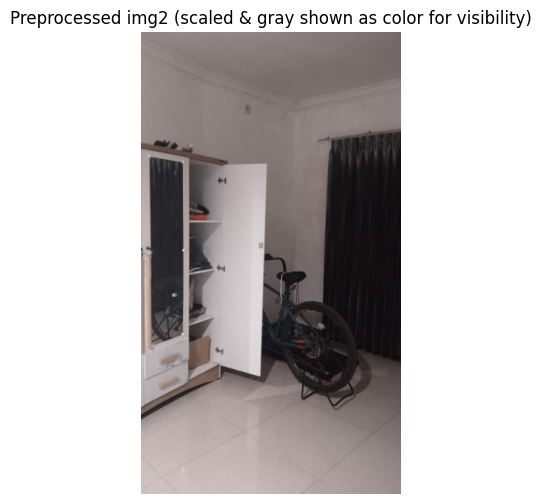

In [ ]:
# Cell: Preprocessing
scale = 0.5       # ubah kalau mau deteksi di resolusi penuh
equalize = True

def preprocess(img, scale=0.5, equalize_hist=True):
    h,w = img.shape[:2]
    img_small = cv2.resize(img, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_AREA)
    gray = cv2.cvtColor(img_small, cv2.COLOR_BGR2GRAY)
    if equalize_hist:
        gray = cv2.equalizeHist(gray)
    return img_small, gray

img1_small, gray1 = preprocess(img1, scale=scale, equalize_hist=equalize)
img2_small, gray2 = preprocess(img2, scale=scale, equalize_hist=equalize)
show(img1_small, "Preprocessed img1 (scaled & gray shown as color for visibility)")
show(img2_small, "Preprocessed img2 (scaled & gray shown as color for visibility)")


Detected 800 keypoints in image1, 379 in image2


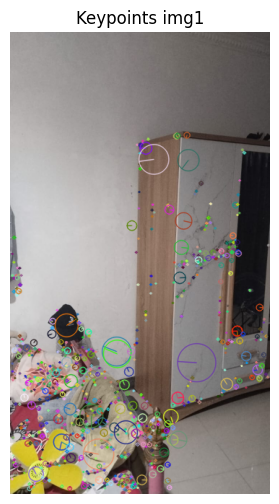

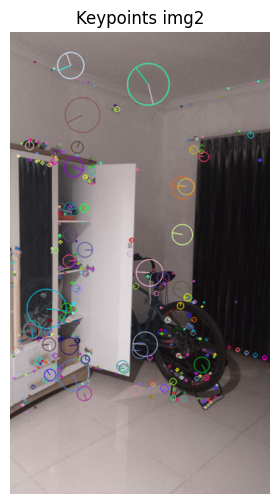

In [ ]:
# Cell: Detect & compute descriptors
kps1, desc1 = detector.detectAndCompute(gray1, None)
kps2, desc2 = detector.detectAndCompute(gray2, None)

print(f"Detected {len(kps1)} keypoints in image1, {len(kps2)} in image2")

# visualize keypoints on the scaled color images
kp_img1 = draw_keypoints_bgr(img1_small, kps1)
kp_img2 = draw_keypoints_bgr(img2_small, kps2)
show(kp_img1, "Keypoints img1")
show(kp_img2, "Keypoints img2")


Found 20 good matches (after ratio test)


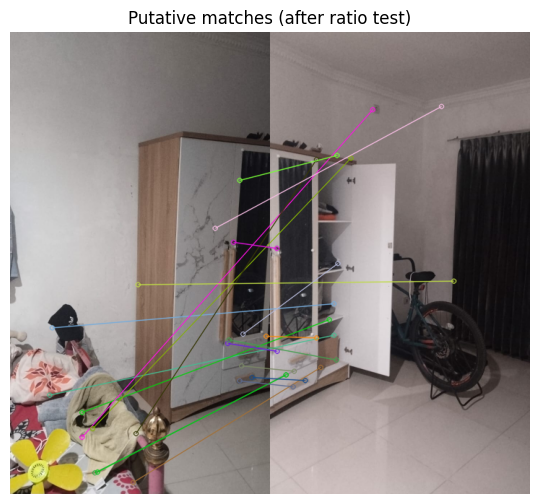

In [ ]:
# Cell: Match descriptors (BF + Lowe's ratio test)
def match_descriptors(desc1, desc2, method='SIFT', ratio_thresh=0.75):
    if desc1 is None or desc2 is None:
        return []
    if method == 'SIFT':
        bf = cv2.BFMatcher(cv2.NORM_L2)
    else:
        bf = cv2.BFMatcher(cv2.NORM_HAMMING)
    knn = bf.knnMatch(desc1, desc2, k=2)
    good = []
    for m_n in knn:
        if len(m_n) < 2:
            continue
        m, n = m_n
        if m.distance < ratio_thresh * n.distance:
            good.append(m)
    return good

matches = match_descriptors(desc1, desc2, method=descriptor_method, ratio_thresh=0.75)
print(f"Found {len(matches)} good matches (after ratio test)")
match_vis = draw_matches_bgr(img1_small, kps1, img2_small, kps2, matches, max_display=200)
show(match_vis, "Putative matches (after ratio test)")


Estimated homography (on scaled images):
 [[ 4.88756970e-01 -1.07459958e-02  3.20325180e+02]
 [-4.78973572e-01  1.09729857e+00 -2.17641675e+01]
 [-1.49892293e-03  1.77339071e-04  1.00000000e+00]]
Inliers: 6 / 20


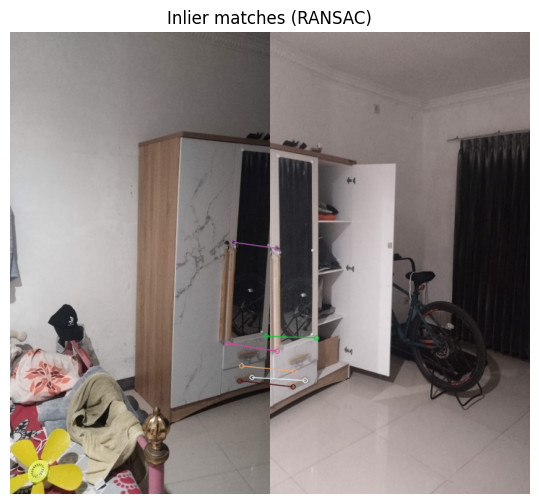

In [ ]:
def estimate_homography(kps1, kps2, matches, reproj_thresh=4.0):
    if len(matches) < 4:
        return None, None
    pts1 = np.float32([kps1[m.queryIdx].pt for m in matches])
    pts2 = np.float32([kps2[m.trainIdx].pt for m in matches])
    H, mask = cv2.findHomography(pts2, pts1, cv2.RANSAC, reproj_thresh)
    if mask is None:
        return H, None
    mask = mask.ravel().astype(bool)
    return H, mask

H_scaled, inlier_mask = estimate_homography(kps1, kps2, matches, reproj_thresh=4.0)
if H_scaled is None:
    raise RuntimeError("Homography estimation failed (not enough matches).")

print("Estimated homography (on scaled images):\n", H_scaled)
print("Inliers:", np.sum(inlier_mask), "/", len(matches))

# visualize inlier matches only
inlier_matches = [m for i,m in enumerate(matches) if inlier_mask[i]]
inlier_vis = draw_matches_bgr(img1_small, kps1, img2_small, kps2, inlier_matches, max_display=200)
show(inlier_vis, "Inlier matches (RANSAC)")


In [ ]:
# Cell: Adjust homography from scaled images to full-resolution images
s = scale
S = np.diag([1/s, 1/s, 1.0])   # scale-up matrix for mapping from scaled->original
H_full = S.dot(H_scaled).dot(np.linalg.inv(S))
print("Homography mapped to full-resolution images:\n", H_full)


Homography mapped to full-resolution images:
 [[ 4.88756970e-01 -1.07459958e-02  6.40650359e+02]
 [-4.78973572e-01  1.09729857e+00 -4.35283350e+01]
 [-7.49461464e-04  8.86695356e-05  1.00000000e+00]]


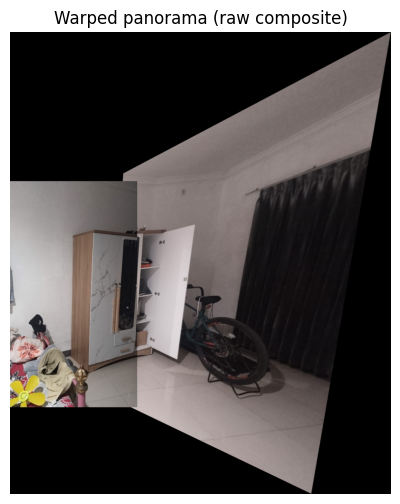

In [ ]:
# Cell: Warping image2 into image1 coordinate frame and building panorama canvas
def warp_images(img1, img2, H):
    h1,w1 = img1.shape[:2]
    h2,w2 = img2.shape[:2]
    corners2 = np.float32([[0,0],[0,h2],[w2,h2],[w2,0]]).reshape(-1,1,2)
    warped_c2 = cv2.perspectiveTransform(corners2, H)
    corners1 = np.float32([[0,0],[0,h1],[w1,h1],[w1,0]]).reshape(-1,1,2)
    all_corners = np.concatenate((warped_c2, corners1), axis=0)
    [xmin,ymin] = np.int32(all_corners.min(axis=0).ravel() - 0.5)
    [xmax,ymax] = np.int32(all_corners.max(axis=0).ravel() + 0.5)
    t = [-xmin, -ymin]
    H_translate = np.array([[1,0,t[0]],[0,1,t[1]],[0,0,1]], dtype=np.float64)
    output_size = (xmax - xmin, ymax - ymin)
    result = cv2.warpPerspective(img2, H_translate.dot(H), output_size)
    result[t[1]:t[1]+h1, t[0]:t[0]+w1] = img1
    return result, H_translate, t, output_size

panorama_raw, Htrans, t, out_size = warp_images(img1, img2, H_full)
show(panorama_raw, "Warped panorama (raw composite)")


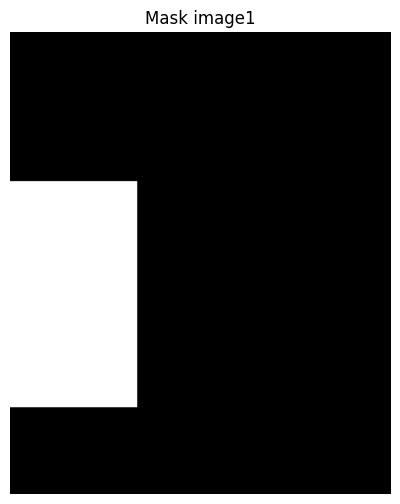

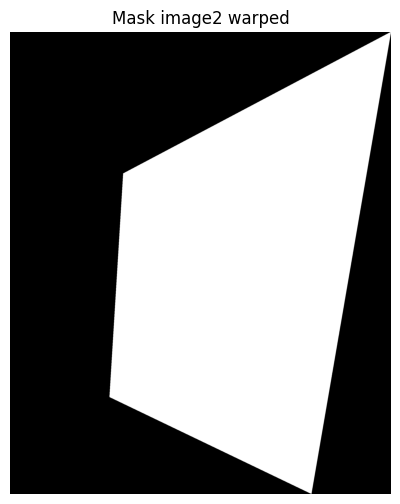

In [ ]:
# Cell: Masks & warped-only img2
h_out, w_out = panorama_raw.shape[:2]

# mask for image1 placed in canvas
mask1 = np.zeros((h_out, w_out), dtype=np.uint8)
h1,w1 = img1.shape[:2]
mask1[t[1]:t[1]+h1, t[0]:t[0]+w1] = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY) > 0

# mask for img2 after warp
img2_warped = cv2.warpPerspective(img2, Htrans.dot(H_full), out_size)
mask2 = cv2.cvtColor(img2_warped, cv2.COLOR_BGR2GRAY) > 0

show((mask1*255).astype(np.uint8), "Mask image1", cmap='gray')
show((mask2*255).astype(np.uint8), "Mask image2 warped", cmap='gray')


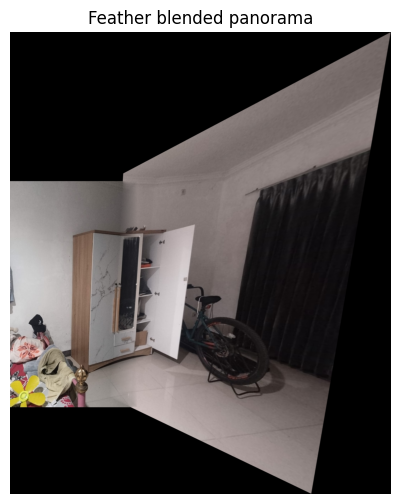

In [ ]:
# Cell: Distance-weighted feather blending
def distance_weighted_blend(img1_canv, img2_warp, mask1, mask2):
    eps = 1e-6
    d1 = ndimage.distance_transform_edt(mask1.astype(np.uint8))
    d2 = ndimage.distance_transform_edt(mask2.astype(np.uint8))
    w1 = d1 / (d1 + d2 + eps)
    w2 = d2 / (d1 + d2 + eps)
    w1 = np.repeat(w1[:,:,None],3,axis=2)
    w2 = np.repeat(w2[:,:,None],3,axis=2)
    blended = (img1_canv.astype(np.float32)*w1 + img2_warp.astype(np.float32)*w2)
    blended = np.clip(blended,0,255).astype(np.uint8)
    return blended

canvas1 = np.zeros_like(panorama_raw)
canvas1[t[1]:t[1]+h1, t[0]:t[0]+w1] = img1
canvas2 = img2_warped.copy()

blended = distance_weighted_blend(canvas1, canvas2, mask1, mask2)
show(blended, "Feather blended panorama")


In [ ]:
# Cell: Laplacian pyramid blending (optional, slower)
def laplacian_pyramid_blend(A, B, mask, levels=4):
    # mask: single-channel float [0,1]
    GA = A.astype(np.float32)
    GB = B.astype(np.float32)
    GM = mask.astype(np.float32)
    gpA = [GA]; gpB = [GB]; gpM = [GM]
    for i in range(levels):
        GA = cv2.pyrDown(GA)
        GB = cv2.pyrDown(GB)
        GM = cv2.pyrDown(GM)
        gpA.append(GA); gpB.append(GB); gpM.append(GM)
    lpA = []
    lpB = []
    for i in range(levels):
        LA = gpA[i] - cv2.pyrUp(gpA[i+1], dstsize=gpA[i].shape[:2][::-1])
        LB = gpB[i] - cv2.pyrUp(gpB[i+1], dstsize=gpB[i].shape[:2][::-1])
        lpA.append(LA); lpB.append(LB)
    LS = []
    for la, lb, gm in zip(lpA, lpB, gpM[:-1]):
        LS.append(la*gm + lb*(1-gm))
    res = gpA[-1]*gpM[-1] + gpB[-1]*(1-gpM[-1])
    for i in range(levels-1, -1, -1):
        res = cv2.pyrUp(res, dstsize=LS[i].shape[:2][::-1]) + LS[i]
    res = np.clip(res,0,255).astype(np.uint8)
    return res

# build mask float (smooth)
mask_float = (mask1.astype(np.float32))
mask_float = mask_float / (mask_float.max() + 1e-9)
mask_float = cv2.GaussianBlur(mask_float, (31,31), 0)
mask_float_3 = np.repeat(mask_float[:,:,None],3,axis=2)

try:
    lap_blend = laplacian_pyramid_blend(canvas1, canvas2, mask_float_3[:,:,0:1], levels=4)
    show(lap_blend, "Pyramid blended panorama (alternative)")
except Exception as e:
    print("Pyramid blending failed:", e)


Pyramid blending failed: operands could not be broadcast together with shapes (1308,1078,3) (1308,1078) 


Saved panorama to panorama_sift.jpg


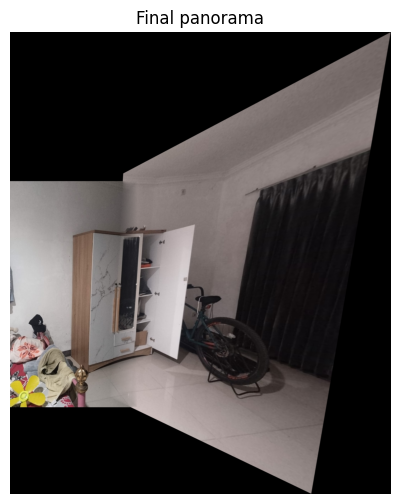

In [ ]:
# Cell: Save results
final = blended    # or lap_blend if you prefer
out_name = "panorama_sift.jpg"
cv2.imwrite(out_name, final)
print("Saved panorama to", out_name)
show(final, "Final panorama")


## Ringkasan konsep (mengutip Bab 4 & Bab 9 Szeliski)

- **Feature detection & descriptor (Bab 4)**: SIFT mendeteksi keypoint skala-invariant dan membangun descriptor gradien (biasanya 128D) yang tahan terhadap rotasi, skala, dan perubahan pencahayaan kecil. Pencocokan dilakukan dengan nearest neighbor + ratio test (Lowe) untuk mengurangi kecocokan ambigu.
- **Geometric verification (Bab 9)**: Gunakan RANSAC untuk memisahkan inlier dari outlier dan mengestimasi homography 3×3 yang memetakan koordinat antar gambar (berguna untuk panorama bila panorama dapat dimodelkan oleh homography: planar scene atau pure rotation).
- **Warping & compositing**: `warpPerspective` menerapkan homography; bangun canvas yang memuat kedua gambar.  
- **Blending (Bab 9.3)**: Feathering distance-weighted sederhana cukup cepat; multi-band (Laplacian pyramid) menghasilkan transisi yang lebih mulus.

# Image Stitching using ORB — Step-by-step Notebook
Pipeline: preprocessing → ORB keypoints → binary descriptors → matching (Hamming + ratio test) → RANSAC homography → warping → blending.


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
%matplotlib inline

def show(img, title=None, figsize=(10,6), cmap=None):
    plt.figure(figsize=figsize)
    if len(img.shape)==2 or cmap is not None:
        plt.imshow(img, cmap=cmap)
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

def draw_keypoints_bgr(img, kps):
    return cv2.drawKeypoints(img, kps, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

def draw_matches_bgr(img1, kps1, img2, kps2, matches, max_display=100):
    mlist = matches[:max_display]
    return cv2.drawMatches(img1, kps1, img2, kps2, mlist, None,
                           flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

In [ ]:
# ORB configuration
nfeatures = 5000
detector = cv2.ORB_create(nfeatures=nfeatures)
descriptor_method = 'ORB'

print("Using ORB detector with", nfeatures, "features.")


Using ORB detector with 5000 features.


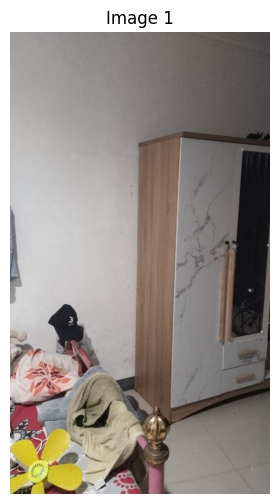

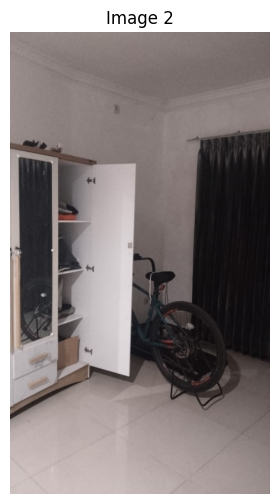

In [ ]:
img1_path = "left.jpg"
img2_path = "right.jpg"

import os
img1 = cv2.imread(img1_path)
img2 = cv2.imread(img2_path)
if img1 is None or img2 is None:
    raise FileNotFoundError("Cek path gambar")

show(img1, "Image 1")
show(img2, "Image 2")


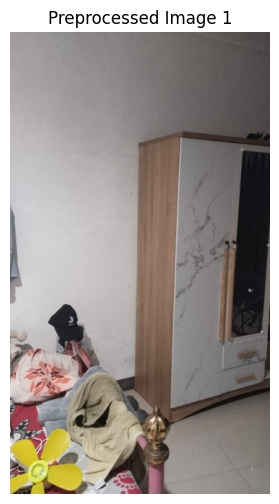

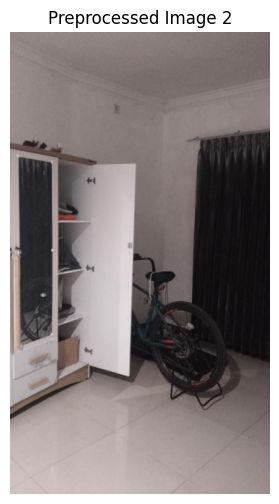

In [ ]:
scale = 0.5
equalize = True

def preprocess(img, scale=0.5, equalize_hist=True):
    h,w = img.shape[:2]
    img_small = cv2.resize(img, (int(w*scale), int(h*scale)))
    gray = cv2.cvtColor(img_small, cv2.COLOR_BGR2GRAY)
    if equalize_hist:
        gray = cv2.equalizeHist(gray)
    return img_small, gray

img1_small, gray1 = preprocess(img1, scale, equalize)
img2_small, gray2 = preprocess(img2, scale, equalize)

show(img1_small, "Preprocessed Image 1")
show(img2_small, "Preprocessed Image 2")


Image1: 2562 keypoints
Image2: 1056 keypoints


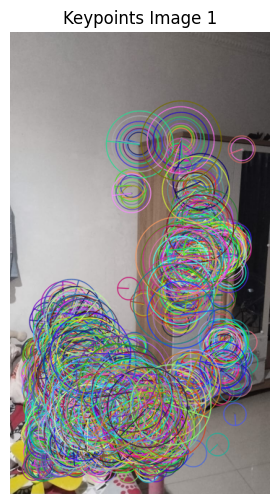

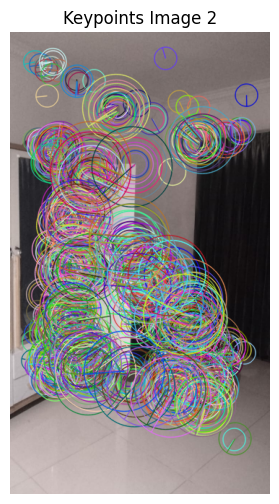

In [ ]:
kps1, desc1 = detector.detectAndCompute(gray1, None)
kps2, desc2 = detector.detectAndCompute(gray2, None)

print("Image1:", len(kps1), "keypoints")
print("Image2:", len(kps2), "keypoints")

show(draw_keypoints_bgr(img1_small, kps1), "Keypoints Image 1")
show(draw_keypoints_bgr(img2_small, kps2), "Keypoints Image 2")


Good matches: 14


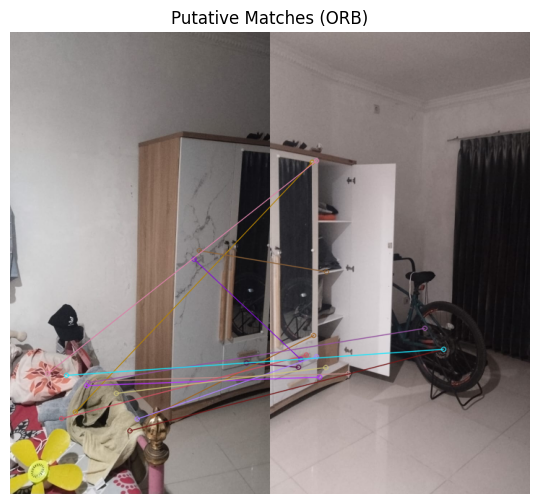

In [ ]:
def match_descriptors(desc1, desc2, ratio_thresh=0.75):
    bf = cv2.BFMatcher(cv2.NORM_HAMMING)
    knn = bf.knnMatch(desc1, desc2, k=2)
    good = []
    for m,n in knn:
        if m.distance < ratio_thresh * n.distance:
            good.append(m)
    return good

matches = match_descriptors(desc1, desc2, ratio_thresh=0.75)
print("Good matches:", len(matches))

show(draw_matches_bgr(img1_small, kps1, img2_small, kps2, matches),
     "Putative Matches (ORB)")


Homography (scaled):
 [[-4.32850929e-01 -2.70433720e-01  1.37229498e+02]
 [-2.68396798e+00 -9.97197441e-01  5.60185116e+02]
 [-5.59799020e-03 -1.71848153e-03  1.00000000e+00]]
Inliers: 4 / 14


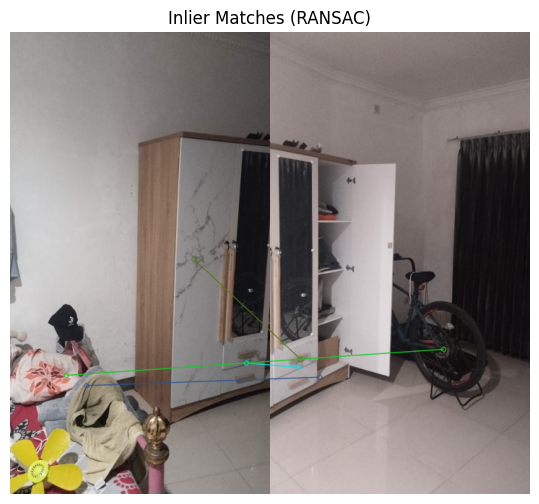

In [ ]:
def estimate_homography(kps1, kps2, matches, thresh=4.0):
    if len(matches) < 4:
        return None, None
    pts1 = np.float32([kps1[m.queryIdx].pt for m in matches])
    pts2 = np.float32([kps2[m.trainIdx].pt for m in matches])
    H, mask = cv2.findHomography(pts2, pts1, cv2.RANSAC, thresh)
    return H, mask.ravel().astype(bool)

H_scaled, mask = estimate_homography(kps1, kps2, matches)
print("Homography (scaled):\n", H_scaled)
print("Inliers:", np.sum(mask), "/", len(matches))

inlier_matches = [m for i, m in enumerate(matches) if mask[i]]
show(draw_matches_bgr(img1_small, kps1, img2_small, kps2, inlier_matches),
     "Inlier Matches (RANSAC)")


In [ ]:
S = np.diag([1/scale, 1/scale, 1])
H_full = S @ H_scaled @ np.linalg.inv(S)
print("Homography (full resolution):\n", H_full)


Homography (full resolution):
 [[-4.32850929e-01 -2.70433720e-01  2.74458996e+02]
 [-2.68396798e+00 -9.97197441e-01  1.12037023e+03]
 [-2.79899510e-03 -8.59240765e-04  1.00000000e+00]]


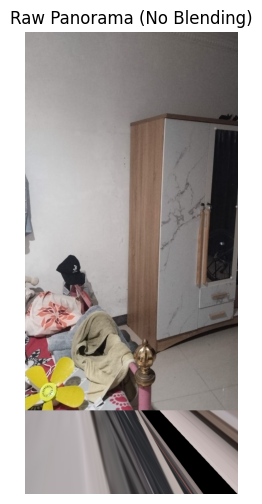

In [ ]:
def warp_images(img1, img2, H):
    h1,w1 = img1.shape[:2]
    h2,w2 = img2.shape[:2]

    corners2 = np.float32([[0,0],[0,h2],[w2,h2],[w2,0]]).reshape(-1,1,2)
    warped_c2 = cv2.perspectiveTransform(corners2, H)

    corners1 = np.float32([[0,0],[0,h1],[w1,h1],[w1,0]]).reshape(-1,1,2)
    all_c = np.concatenate([warped_c2, corners1], axis=0)

    [xmin,ymin] = np.int32(all_c.min(axis=0).ravel() - 0.5)
    [xmax,ymax] = np.int32(all_c.max(axis=0).ravel() + 0.5)

    shift = [-xmin, -ymin]
    Ht = np.array([[1,0,shift[0]],
                   [0,1,shift[1]],
                   [0,0,1]])

    size = (xmax - xmin, ymax - ymin)

    result = cv2.warpPerspective(img2, Ht @ H, size)
    result[shift[1]:shift[1]+h1, shift[0]:shift[0]+w1] = img1

    return result, Ht, shift, size

panorama_raw, Ht, shift, out_size = warp_images(img1, img2, H_full)
show(panorama_raw, "Raw Panorama (No Blending)")


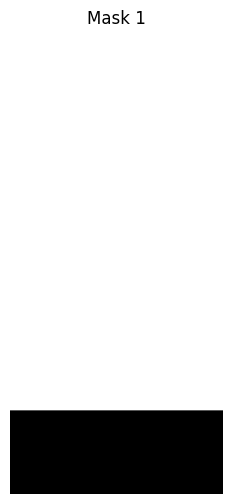

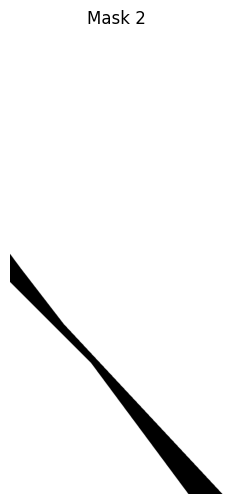

In [ ]:
h_out, w_out = panorama_raw.shape[:2]

mask1 = np.zeros((h_out, w_out), dtype=np.uint8)
h1,w1 = img1.shape[:2]
mask1[shift[1]:shift[1]+h1, shift[0]:shift[0]+w1] = 1

img2_warped = cv2.warpPerspective(img2, Ht @ H_full, out_size)
mask2 = (cv2.cvtColor(img2_warped, cv2.COLOR_BGR2GRAY) > 0).astype(np.uint8)

show(mask1*255, "Mask 1", cmap='gray')
show(mask2*255, "Mask 2", cmap='gray')


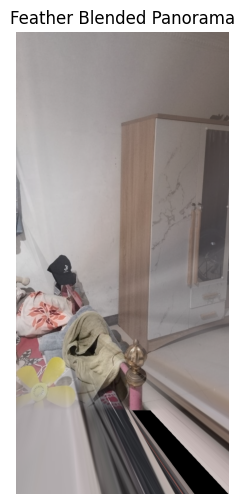

In [ ]:
def feather_blend(imgA, imgB, maskA, maskB):
    eps = 1e-6
    d1 = ndimage.distance_transform_edt(maskA)
    d2 = ndimage.distance_transform_edt(maskB)
    wA = d1 / (d1 + d2 + eps)
    wB = d2 / (d1 + d2 + eps)
    wA = np.repeat(wA[:, :, None], 3, axis=2)
    wB = np.repeat(wB[:, :, None], 3, axis=2)
    out = imgA * wA + imgB * wB
    return np.clip(out, 0, 255).astype(np.uint8)

canvas1 = np.zeros_like(panorama_raw)
canvas1[shift[1]:shift[1]+h1, shift[0]:shift[0]+w1] = img1

canvas2 = img2_warped.copy()

blended = feather_blend(canvas1, canvas2, mask1, mask2)
show(blended, "Feather Blended Panorama")


Saved as panorama_orb.jpg


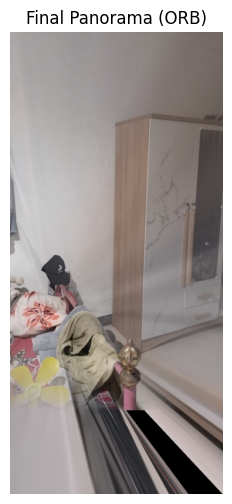

In [ ]:
cv2.imwrite("panorama_orb.jpg", blended)
print("Saved as panorama_orb.jpg")
show(blended, "Final Panorama (ORB)")
